# Acea Smart Water - Lake Bilacino

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importo mis datos en un dataframe

In [ ]:
df = pd.read_csv('../data/raw/Lake_Bilancino.csv')

Obtengo 5 filas aleatorias para tener contexto

In [ ]:
df.sample(5)

Transformo mi columna Date en formato de fechas

In [ ]:
from datetime import datetime, date 

df['Date'] = pd.to_datetime(df['Date'], format = '%d/%m/%Y')
df.head()

In [ ]:
f, ax = plt.subplots(nrows=8, ncols=1, figsize=(15, 25))

for i, column in enumerate(df.drop('Date', axis=1).columns):
    sns.lineplot(x=df['Date'], y=df[column].ffill(), ax=ax[i], color='blue')
    ax[i].set_title('Feature: {}'.format(column), fontsize=14)
    ax[i].set_ylabel(ylabel=column, fontsize=14)
                      
    ax[i].set_xlim([date(2009, 1, 1), date(2020, 6, 30)])    

Antes de continuar, primero voy a asegurarme de que mis datos sigan una progresion diaria

In [ ]:
diferencias = df['Date'].diff()
diferencias.max()

Confirmo que mis datos son series temporales de 1 dia

Voy a tomar mis datos de Lake_Level y su desarrollo sobre el tiempo, intentare predecir el nivel del agua a lo largo del tiempo

In [ ]:
df = df[['Date', 'Lake_Level']].copy()

Marco la columna de fechas como mi indice

In [ ]:
df.set_index('Date', inplace=True)
df

Visualizo mis datos.

In [ ]:
sns.lineplot(data = df)

## Decomposicion de la serie - Diaria

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df, period = 365) # Dado que he comprobado que son datos diarios usare un periodo diario

## Analisis de tendencia

In [ ]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = trend)


plt.tight_layout()

plt.show()

## Analisis de estacionalidad

In [ ]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df)

Esto me confirma que mis datos son estacionales, ya que mi prueba Dickey-Fuller me indica que el p-value es menor de 0.05. Se rechaza la hipotesis nula de presencia de una raíz unitaria. 

## Analisis de variabilidad

In [ ]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

## Analisis de autocorrelacion

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df)

plt.tight_layout()

plt.show()

Se puede observar una alta correlacion que disminuye sobre el tiempo, pero manteniendose alta

## Entrenamiento del modelo

In [25]:
from pmdarima import auto_arima

y_train = df

model = auto_arima(
    df, start_p=1, start_q=1,
    max_p=3, max_q=3,
    m=12,
    d=0,                 # si ya confirmaste que no requiere diferenciación
    seasonal=True,      # si no hay estacionalidad
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=-12162.838, Time=6.19 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=28988.108, Time=0.05 sec


c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=2.45 sec


c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,0,3)(0,0,2)[12] intercept   : AIC=-12503.627, Time=11.73 sec


c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,3)(0,0,2)[12] intercept   : AIC=-12571.078, Time=20.63 sec


c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,3)(0,0,2)[12]             : AIC=inf, Time=7.23 sec

Best model:  ARIMA(2,0,3)(0,0,2)[12] intercept
Total fit time: 406.409 seconds


In [26]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                 6603
Model:             SARIMAX(2, 0, 3)x(0, 0, [1, 2], 12)   Log Likelihood                6300.735
Date:                                 Tue, 15 Apr 2025   AIC                         -12583.469
Time:                                         00:50:05   BIC                         -12522.312
Sample:                                     06-03-2002   HQIC                        -12562.334
                                          - 06-30-2020                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4957      0.098      5.076      0.000       0.304       0.687
ar.L1          1.7551      0.027     66.007      0.000       1.703       1.807
ar.L2         -0.7571      0.026    -28.690      0.000      -0.809      -0.705
ma.L1         -0.3816      0.026    -14.509      0.000      -0.433      -0.330
ma.L2         -0.0564      0.010     -5.399      0.000      -0.077      -0.036
ma.L3         -0.0316      0.013     -2.438      0.015      -0.057      -0.006
ma.S.L12       0.0154      0.008      1.871      0.061      -0.001       0.032
ma.S.L24       0.0534      0.009      6.141      0.000       0.036       0.070
sigma2         0.0087   3.23e-05    268.834      0.000       0.009       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2124405.52
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.52   Skew:                             5.68
Prob(H) (two-sided):                  0.00   Kurtosis:                        90.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Prediccion del modelo

In [27]:
forecast = model.predict(365) # Predecimos una año completo

c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


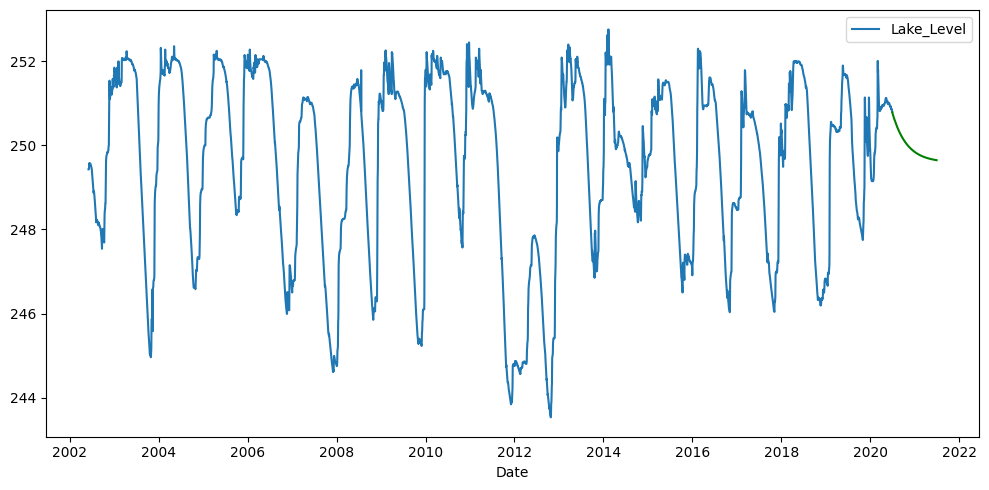

In [28]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()